In [1]:
print("""1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.""")

1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.regressionplots import influence_plot
import statsmodels.formula.api as smf
import numpy as np
sns.set_theme(style='darkgrid', palette='rainbow')

In [3]:
Toyota_data = pd.read_csv("ToyotaCorolla - MLR.csv")
Toyota_data

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


# EDA

In [4]:
Toyota_data.shape

(1436, 11)

In [5]:
Toyota_data.dtypes

Price         int64
Age_08_04     int64
KM            int64
Fuel_Type    object
HP            int64
Automatic     int64
cc            int64
Doors         int64
Cylinders     int64
Gears         int64
Weight        int64
dtype: object

In [6]:
Toyota_data.isna().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [7]:
Toyota_data.duplicated().sum()

np.int64(1)

<Axes: >

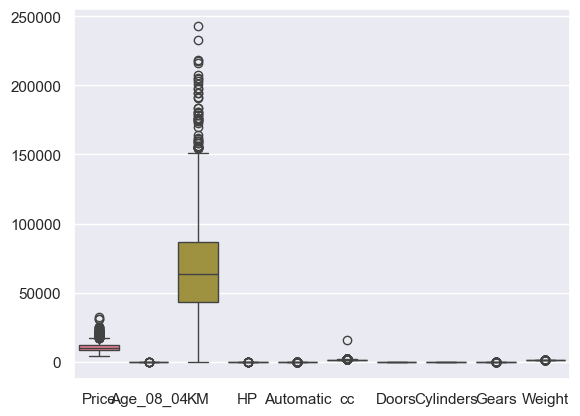

In [8]:
sns.boxplot(data=Toyota_data)

In [9]:
Toyota_data["Age_08_04"].skew()

np.float64(-0.82670187309842)

In [10]:
Toyota_data["Gears"].skew()

np.float64(2.283959738160194)

In [11]:
Toyota_data["Automatic"].skew()

np.float64(3.878196903617749)

In [12]:
Toyota_data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


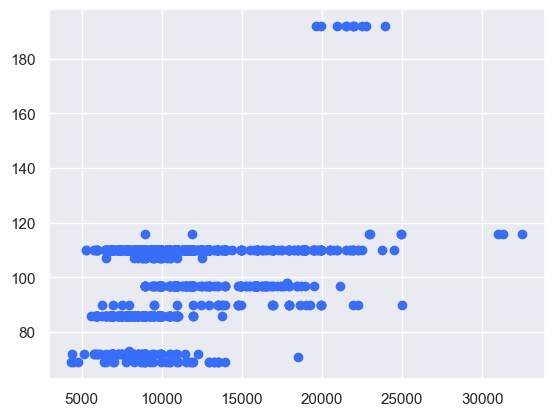

In [13]:
plt.scatter(x='Price',y='HP', data=Toyota_data)

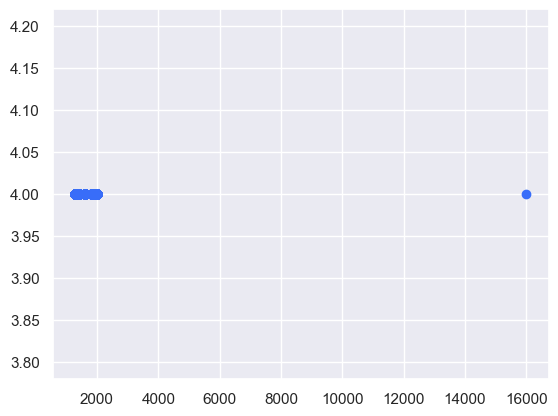

In [14]:
plt.scatter(x='cc',y='Cylinders',data=Toyota_data)

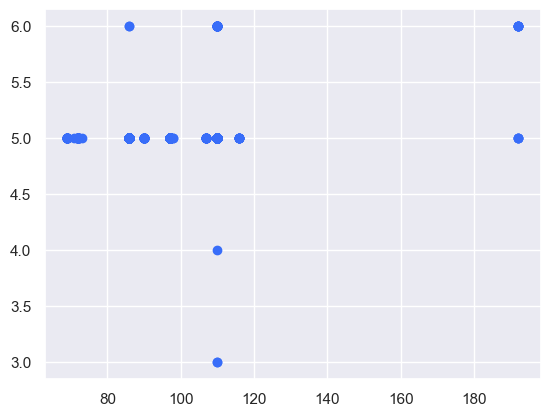

In [15]:
plt.scatter(x='HP', y='Gears', data=Toyota_data)

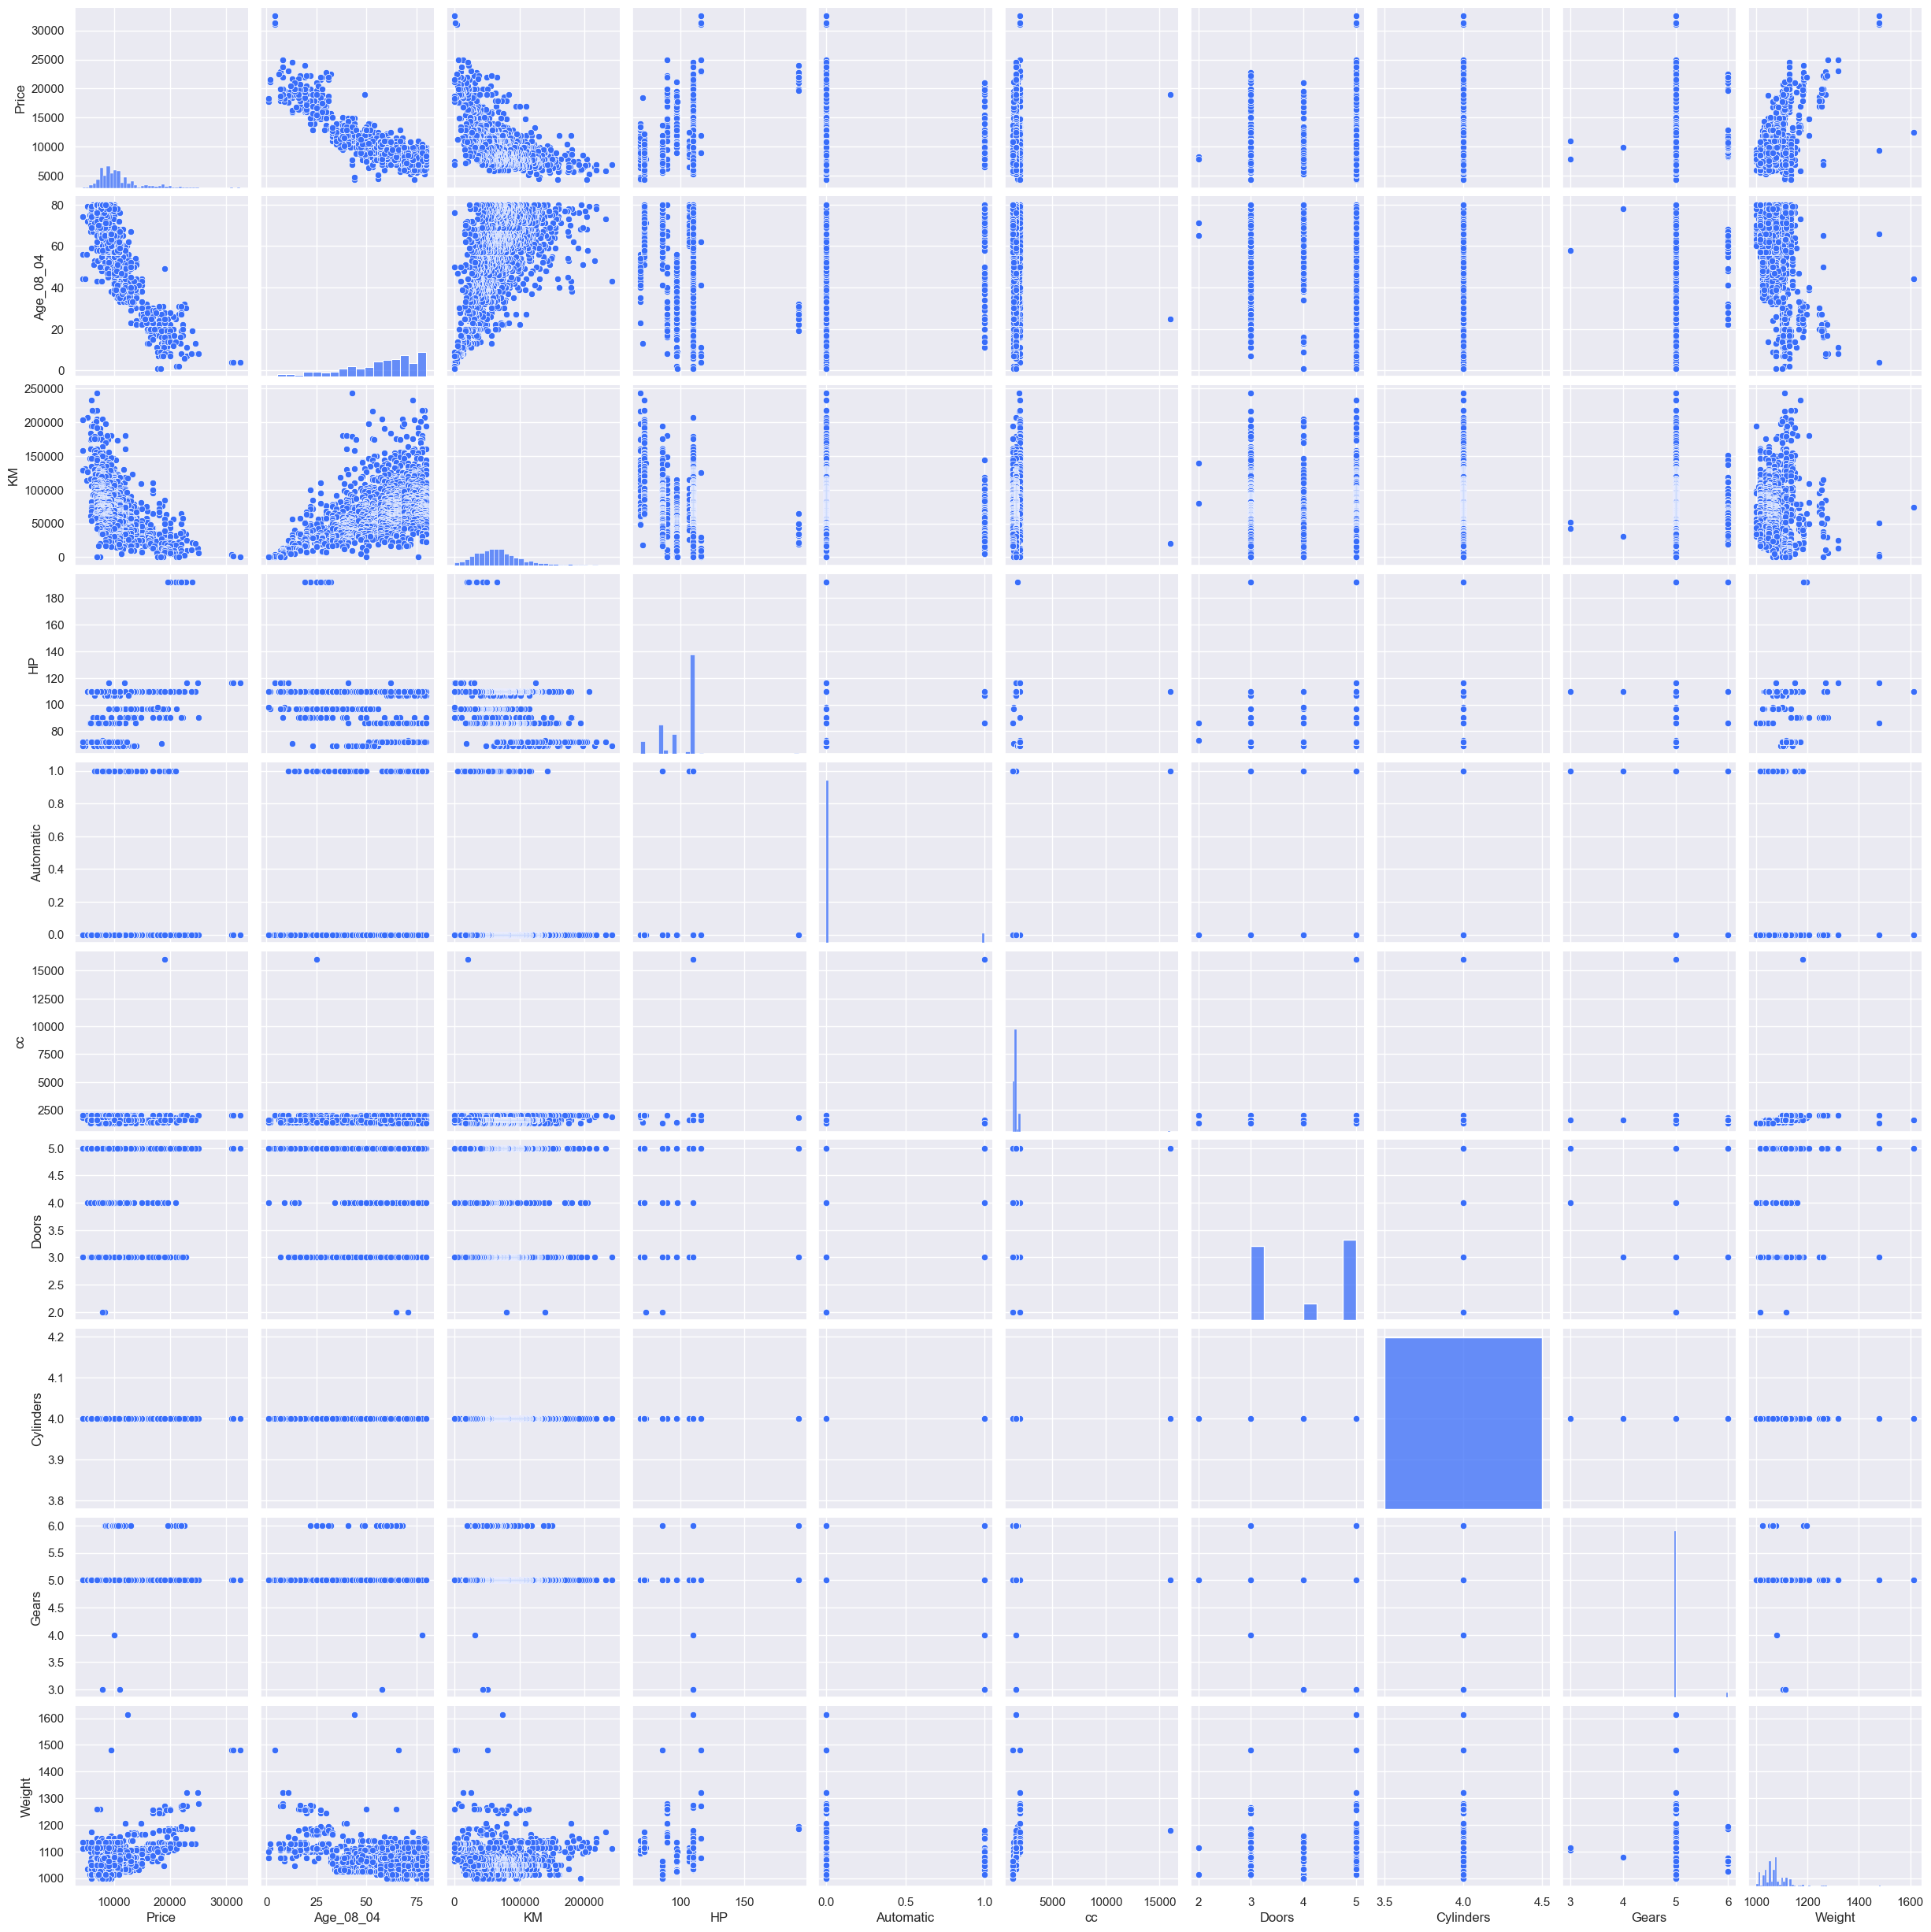

In [16]:
sns.pairplot(Toyota_data)

In [17]:
Toyota_data.corr

<bound method DataFrame.corr of       Price  Age_08_04     KM Fuel_Type   HP  Automatic    cc  Doors  \
0     13500         23  46986    Diesel   90          0  2000      3   
1     13750         23  72937    Diesel   90          0  2000      3   
2     13950         24  41711    Diesel   90          0  2000      3   
3     14950         26  48000    Diesel   90          0  2000      3   
4     13750         30  38500    Diesel   90          0  2000      3   
...     ...        ...    ...       ...  ...        ...   ...    ...   
1431   7500         69  20544    Petrol   86          0  1300      3   
1432  10845         72  19000    Petrol   86          0  1300      3   
1433   8500         71  17016    Petrol   86          0  1300      3   
1434   7250         70  16916    Petrol   86          0  1300      3   
1435   6950         76      1    Petrol  110          0  1600      5   

      Cylinders  Gears  Weight  
0             4      5    1165  
1             4      5    1165  
2   

In [18]:
print("""2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).""")

2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).


In [19]:
# . Split Dataset into Train & Test Split

from sklearn.model_selection import train_test_split

# Define target variable (Price) and feature variables
X = Toyota_data.drop("Price", axis=1)   # Independent variables
y = Toyota_data["Price"]                # Dependent variable

# Split the dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

# Display the shape of each dataset
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

# Display the number of records
print("\nNumber of Training Samples :", len(X_train))
print("Number of Testing Samples  :", len(X_test))

Training Features Shape : (1148, 10)
Testing Features Shape  : (288, 10)
Training Target Shape   : (1148,)
Testing Target Shape    : (288,)

Number of Training Samples : 1148
Number of Testing Samples  : 288


In [20]:
print("""Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models""")

Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [22]:
# One-Hot Encoding
df = pd.get_dummies(Toyota_data, columns=['Fuel_Type'], drop_first=True)

In [23]:
# Features and Target
X = df.drop("Price", axis=1)
y = df["Price"]

In [24]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.20,random_state=42)


In [25]:
# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# Prediction
y_pred = model.predict(X_test)

In [27]:
# Coefficients
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})


In [28]:
print(coefficients)
print("\nIntercept:", model.intercept_)
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

             Feature   Coefficient
0          Age_08_04 -1.208305e+02
1                 KM -1.623141e-02
2                 HP  1.403948e+01
3          Automatic  1.488309e+02
4                 cc -3.037219e-02
5              Doors -6.031097e+01
6          Cylinders  6.536993e-13
7              Gears  5.516007e+02
8             Weight  2.588496e+01
9   Fuel_Type_Diesel -6.854876e+01
10  Fuel_Type_Petrol  1.370809e+03

Intercept: -14255.385993565298
R² Score: 0.8348888040611084
MAE: 990.8872739193926
RMSE: 1484.2654153296505


In [29]:
print("""Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset""")

Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset


In [30]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [31]:
# Predict on test data
y_pred = model.predict(X_test)

In [32]:
# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print Results
print("Model Performance on Test Data")
print("--------------------------------")
print("R² Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)


Model Performance on Test Data
--------------------------------
R² Score : 0.8348888040611084
MAE      : 990.8872739193926
MSE      : 2203043.8231437
RMSE     : 1484.2654153296505


In [33]:
print("""Apply Lasso and Ridge methods on the model.""")

Apply Lasso and Ridge methods on the model.


In [34]:

from sklearn.linear_model import Ridge, Lasso

In [35]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [36]:
# Prediction
ridge_pred = ridge_model.predict(X_test)
# Evaluation
print("===== Ridge Regression =====")
print("R² Score :", r2_score(y_test, ridge_pred))
print("MAE      :", mean_absolute_error(y_test, ridge_pred))
print("MSE      :", mean_squared_error(y_test, ridge_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, ridge_pred)))


===== Ridge Regression =====
R² Score : 0.835135937771234
MAE      : 990.733834202601
MSE      : 2199746.3702333346
RMSE     : 1483.1541963778866


In [37]:
# -------------------------------
# Lasso Regression
#
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

# Prediction
lasso_pred = lasso_model.predict(X_test)

# Evaluation
print("\n===== Lasso Regression =====")
print("R² Score :", r2_score(y_test, lasso_pred))
print("MAE      :", mean_absolute_error(y_test, lasso_pred))
print("MSE      :", mean_squared_error(y_test, lasso_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, lasso_pred)))


===== Lasso Regression =====
R² Score : 0.8354626403967389
MAE      : 990.9546616159033
MSE      : 2195387.2460865397
RMSE     : 1481.6839224634043


In [38]:
print("""6. Deployment with Streamlit:
In this task, you will deploy your logistic regression model using Streamlit.
The deployment can be done locally or online via Streamlit Share. 
Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions.""")


6. Deployment with Streamlit:
In this task, you will deploy your logistic regression model using Streamlit.
The deployment can be done locally or online via Streamlit Share. 
Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions.


In [39]:
from pickle import load

model = load(open('MultipleLinearRegression.pkl', 'rb'))